###
UK Train Rides Analysis 

# 🚆 UK Train Rides Analysis

## Project Overview
This project analyzes UK train ride data to find insights about passengers, revenue, and delays.

---

### 🎯 Objectives
- Analyze passenger trends
- Check revenue performance
- Study delay patterns

### 🛠️ Tools
- Python
- Pandas
- Matplotlib

### 📊 KPIs
| KPI | Description |
|-----|-------------|
| Total Revenue | Sum of all ticket prices |
| Total Passengers | Total number of journeys |
| Average Ticket Price | Mean price per ticket |
| Delay Rate | % of delayed or cancelled journeys |

---

### 👥 Team

| Week | Topic | Members |
|------|-------|---------|
| Week 1 | Data Cleaning & Preprocessing | Mohamed Omar & Ahmed Reda |
| Week 2 | Analysis Questions | Ahmed Elsayed & Joseph Milad |
| Week 3 | Forecasting Questions | Kerols Raafat & Yahya Ebrahim |

---

> **Dataset:** UK Railway — Jan to Apr 2024 | 31,653 rows × 18 columns

## 📋 Week 1 — Data Cleaning & Preprocessing

| # | Question |
|---|----------|
| **Data Quality** | |
| 1 | Identify all columns containing null values and their counts, and determine whether each is logically justified based on journey status or not. |
| 2 | Identify all columns that need data type conversion and cast them to their appropriate types. |
| 3 | Inspect the "Reason for Delay" column and fix any inconsistent or duplicate values. |
| **Feature Engineering** | |
| 4 | Calculate the actual delay in minutes for each journey, and the number of days between purchase date and journey date. |
| 5 | Extract from the date and time columns: purchase hour, day name, month, and a flag indicating whether the journey falls on a weekend or not. |
| **Deliverable** | |
| 6 | Verify the final cleaned dataset is ready for analysis and display a summary of row count, column count, and any remaining justified nulls. |

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print('Libraries loaded successfully ')

Libraries loaded successfully 


## Q2 — Load Dataset
Place `railway.csv` in the same folder as this notebook, then run the cell.

In [2]:
df = pd.read_csv('railway.csv')

df_original = df.copy()

print(f'Dataset loaded successfully ')
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Dataset loaded successfully 
Rows: 31,653
Columns: 18


## Q3 — Explore Data
Let's look at the first rows, the columns, the data types, and a quick summary.

In [3]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [5]:
df.describe()

,Price
count,31653.000000
mean,23.439200
std,29.997628
min,1.000000
25%,5.000000
50%,11.000000
75%,35.000000
max,267.000000


In [6]:
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

Number of duplicate rows: 0


## Q4 — Check Data Quality
## Q4.1 — Identify columns containing null values
We'll show, for each column with nulls:
- the null count

In [7]:
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_percent
})

null_summary = null_summary[null_summary['Null Count'] > 0]
null_summary = null_summary.sort_values('Null Count', ascending=False)

null_summary

,Null Count,Null %
Reason for Delay,27481,86.82
Railcard,20918,66.09
Actual Arrival Time,1880,5.94


**Logical justification of null values**
| Column | Why nulls appear | Justified? |
|---|---|---|
We will now **verify** that these nulls only appear in the justified situations.

In [8]:
print('Journey Status for rows where Actual Arrival Time is NULL:')
print(df[df['Actual Arrival Time'].isnull()]['Journey Status'].value_counts())

Journey Status for rows where Actual Arrival Time is NULL:
Journey Status
Cancelled    1880
Name: count, dtype: int64


In [9]:
print('Journey Status for rows where Reason for Delay is NULL:')
print(df[df['Reason for Delay'].isnull()]['Journey Status'].value_counts())

Journey Status for rows where Reason for Delay is NULL:
Journey Status
On Time    27481
Name: count, dtype: int64


## Q4.2 — Inspect the `Reason for Delay` column for inconsistencies
Before fixing it, let's see what raw values exist.

In [10]:
print('Unique values in "Reason for Delay" before cleaning:')
print(df['Reason for Delay'].value_counts(dropna=False))

Unique values in "Reason for Delay" before cleaning:
Reason for Delay
NaN                   27481
Weather                 995
Technical Issue         707
Signal Failure          523
Signal failure          447
Staffing                410
Staff Shortage          399
Weather Conditions      377
Traffic                 314
Name: count, dtype: int64


Notice the typical issues here:
- different capitalisation (`weather` vs `Weather`)
- duplicated meaning (`Weather` and `Weather Conditions`)
- extra whitespace / inconsistent spelling (`Staffing`, `Staff Shortage`)

## Q5 — Clean Data

## Q5.1 — Fill `Railcard` nulls with `'None'`
A null railcard means the passenger did not use one — that's a real category, not missing data.

In [11]:
df['Railcard'] = df['Railcard'].fillna('None')

print('Railcard value counts after filling:')
print(df['Railcard'].value_counts())

Railcard value counts after filling:
Railcard
None        20918
Adult        4846
Disabled     3089
Senior       2800
Name: count, dtype: int64


## Q5.2 — Standardize the `Reason for Delay` column
Steps:
1. Strip extra whitespace
2. Convert to title case for consistent capitalisation

In [12]:
df['Reason for Delay'] = df['Reason for Delay'].astype(str).str.strip().str.title()

df['Reason for Delay'] = df['Reason for Delay'].replace('Nan', np.nan)

delay_replacements = {
    'Weather Conditions': 'Weather',
    'Staffing': 'Staff Shortage',
    'Staff': 'Staff Shortage'
}
df['Reason for Delay'] = df['Reason for Delay'].replace(delay_replacements)

print('Unique values in "Reason for Delay" AFTER cleaning:')
print(df['Reason for Delay'].value_counts(dropna=False))

Unique values in "Reason for Delay" AFTER cleaning:
Reason for Delay
NaN                27481
Weather             1372
Signal Failure       970
Staff Shortage       809
Technical Issue      707
Traffic              314
Name: count, dtype: int64


## Q5.3 — Fill the remaining `Reason for Delay` nulls
If the journey was **On Time**, the delay reason is logically `'No Delay'` — not missing data.

In [13]:
df['Reason for Delay'] = df['Reason for Delay'].fillna('No Delay')

print('Final "Reason for Delay" categories:')
print(df['Reason for Delay'].value_counts())

Final "Reason for Delay" categories:
Reason for Delay
No Delay           27481
Weather             1372
Signal Failure       970
Staff Shortage       809
Technical Issue      707
Traffic              314
Name: count, dtype: int64


## Q5.4 — Handle `Actual Arrival Time` nulls
These nulls correspond to **Cancelled** journeys — the train never arrived, so no time exists.
We **keep** these as null because filling them would be incorrect/misleading. This is a *justified* null.

In [14]:
missing_actual = df[df['Actual Arrival Time'].isnull()]
all_cancelled = (missing_actual['Journey Status'] == 'Cancelled').all()
print(f'All missing Actual Arrival Times correspond to Cancelled journeys? {all_cancelled} ')

All missing Actual Arrival Times correspond to Cancelled journeys? True 


## Q6 — Final Dataset
Several columns are stored as plain text but should be converted to proper types:
| Column | Current type | Should be |
|---|---|---|

In [15]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'], errors='coerce')
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'], errors='coerce')

print('Date columns converted ')
print(df[['Date of Purchase', 'Date of Journey']].dtypes)

Date columns converted 
Date of Purchase    datetime64[ns]
Date of Journey     datetime64[ns]
dtype: object


In [16]:
time_columns = ['Time of Purchase', 'Departure Time', 'Arrival Time', 'Actual Arrival Time']

for col in time_columns:
    df[col] = pd.to_datetime(df[col], format='%H:%M:%S', errors='coerce').dt.time

print('Time columns converted ')
df[time_columns].head()

Time columns converted 


,Time of Purchase,Departure Time,Arrival Time,Actual Arrival Time
0,12:41:11,11:00:00,13:30:00,13:30:00
1,11:23:01,09:45:00,11:35:00,11:40:00
2,19:51:27,18:15:00,18:45:00,18:45:00
3,23:00:36,21:30:00,22:30:00,22:30:00
4,18:22:56,16:45:00,19:00:00,19:00:00


In [17]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print(f'Price dtype: {df["Price"].dtype} ')

Price dtype: int64 


In [18]:
category_columns = [
    'Purchase Type',
    'Payment Method',
    'Railcard',
    'Ticket Class',
    'Ticket Type',
    'Journey Status',
    'Reason for Delay',
    'Refund Request'
]

for col in category_columns:
    df[col] = df[col].astype('category')

print('Category conversions done ')
df[category_columns].dtypes

Category conversions done 


Purchase Type       category
Payment Method      category
Railcard            category
Ticket Class        category
Ticket Type         category
Journey Status      category
Reason for Delay    category
Refund Request      category
dtype: object

In [19]:
df.dtypes

Transaction ID                 object
Date of Purchase       datetime64[ns]
Time of Purchase               object
Purchase Type                category
Payment Method               category
Railcard                     category
Ticket Class                 category
Ticket Type                  category
Price                           int64
Departure Station              object
Arrival Destination            object
Date of Journey        datetime64[ns]
Departure Time                 object
Arrival Time                   object
Actual Arrival Time            object
Journey Status               category
Reason for Delay             category
Refund Request               category
dtype: object

## Q7 — Feature Engineering
We now build new useful columns that will help with analysis later.

## Q7.1 — Delay in Minutes
We compute the difference between the **actual arrival time** and the **scheduled arrival time**.
- If the journey was Cancelled → no actual arrival → delay stays NaN.
- If the journey was On Time → delay should be 0 or negative; we keep the real number.

In [20]:
def time_to_minutes(t):
    if pd.isnull(t):
        return np.nan
    return t.hour * 60 + t.minute + t.second / 60

scheduled_minutes = df['Arrival Time'].apply(time_to_minutes)
actual_minutes = df['Actual Arrival Time'].apply(time_to_minutes)

delay = actual_minutes - scheduled_minutes

delay = delay.apply(lambda x: x + 24 * 60 if pd.notnull(x) and x < -60 else x)

df['Delay Minutes'] = delay.round(0)

print('Sample of Delay Minutes by Journey Status:')
print(df.groupby('Journey Status', observed=True)['Delay Minutes'].describe())

Sample of Delay Minutes by Journey Status:
                  count       mean        std  min   25%   50%   75%    max
Journey Status                                                             
Cancelled           0.0        NaN        NaN  NaN   NaN   NaN   NaN    NaN
Delayed          2292.0  42.213351  34.491193  0.0  19.0  37.0  53.0  180.0
On Time         27481.0   0.000000   0.000000  0.0   0.0   0.0   0.0    0.0


## Q7.2 — Days Between Purchase and Journey
Tells us how far in advance the ticket was bought.

In [21]:
df['Days to Journey'] = (df['Date of Journey'] - df['Date of Purchase']).dt.days

print('Days to Journey — quick stats:')
print(df['Days to Journey'].describe())

Days to Journey — quick stats:
count    31653.000000
mean         1.655957
std          3.853255
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         28.000000
Name: Days to Journey, dtype: float64


## Q7.3 — Date / Time Features
Extract:
- Purchase Hour (0-23)
- Day Name (Monday, Tuesday, ...)

In [22]:
df['Purchase Hour'] = df['Time of Purchase'].apply(lambda t: t.hour if pd.notnull(t) else np.nan)

df['Journey Day Name'] = df['Date of Journey'].dt.day_name()
df['Journey Month Name'] = df['Date of Journey'].dt.month_name()

df['Is Weekend'] = df['Date of Journey'].dt.dayofweek.isin([5, 6])

print('New columns created ')
df[['Date of Journey', 'Journey Day Name', 'Journey Month Name', 'Is Weekend', 'Purchase Hour']].head()

New columns created 


,Date of Journey,Journey Day Name,Journey Month Name,Is Weekend,Purchase Hour
0,2024-01-01,Monday,January,False,12
1,2024-01-01,Monday,January,False,11
2,2024-01-02,Tuesday,January,False,19
3,2024-01-01,Monday,January,False,23
4,2024-01-01,Monday,January,False,18


## Q8 — Final Dataset Validation
We now perform a final check to confirm everything is clean.

In [23]:
print(f'Final row count:    {df.shape[0]:,}')
print(f'Final column count: {df.shape[1]}')

Final row count:    31,653
Final column count: 24


In [24]:
final_nulls = df.isnull().sum()
final_nulls = final_nulls[final_nulls > 0]
print('Remaining nulls per column:')
print(final_nulls if len(final_nulls) > 0 else 'No nulls remaining ')

Remaining nulls per column:
Actual Arrival Time    1880
Delay Minutes          1880
dtype: int64


**Are these remaining nulls acceptable?**
| Column | Why it still has nulls | Acceptable? |
|---|---|---|
| `Actual Arrival Time` | Cancelled journeys never arrived — no time exists. | ✅ Yes |

In [25]:
if 'Delay Minutes' in df.columns:
    null_rows = df[df['Actual Arrival Time'].isnull() | df['Delay Minutes'].isnull()]
    print('Journey statuses for the rows that still contain nulls:')
    print(null_rows['Journey Status'].value_counts())

Journey statuses for the rows that still contain nulls:
Journey Status
Cancelled    1880
Delayed         0
On Time         0
Name: count, dtype: int64


In [26]:
df.dtypes

Transaction ID                 object
Date of Purchase       datetime64[ns]
Time of Purchase               object
Purchase Type                category
Payment Method               category
Railcard                     category
Ticket Class                 category
Ticket Type                  category
Price                           int64
Departure Station              object
Arrival Destination            object
Date of Journey        datetime64[ns]
Departure Time                 object
Arrival Time                   object
Actual Arrival Time            object
Journey Status               category
Reason for Delay             category
Refund Request               category
Delay Minutes                 float64
Days to Journey                 int64
Purchase Hour                   int64
Journey Day Name               object
Journey Month Name             object
Is Weekend                       bool
dtype: object

In [27]:
print(f'Duplicate rows in final dataset: {df.duplicated().sum()}')

Duplicate rows in final dataset: 0


## Q9 — Final Clean Dataset Preview

In [28]:
df.head(10)

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Delay Minutes,Days to Journey,Purchase Hour,Journey Day Name,Journey Month Name,Is Weekend
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,No Delay,No,0.0,24,12,Monday,January,False
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No,5.0,16,11,Monday,January,False
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,None,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,No Delay,No,0.0,14,19,Tuesday,January,False
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,None,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,No Delay,No,0.0,12,23,Monday,January,False
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,None,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,No Delay,No,0.0,5,18,Monday,January,False
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,None,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,No Delay,No,0.0,2,7,Monday,January,False
6,1c74479d-85a4-4ba1-a607,2023-12-31,00:02:01,Station,Credit Card,Adult,Standard,Advance,2,London Euston,Oxford,2024-01-01,22:30:00,23:40:00,23:40:00,On Time,No Delay,No,0.0,1,0,Monday,January,False
7,febf8dab-f808-46fa-bf2b,2023-12-31,01:35:18,Station,Contactless,Disabled,Standard,Advance,2,Liverpool Lime Street,Manchester Piccadilly,2024-01-01,00:00:00,00:30:00,00:30:00,On Time,No Delay,No,0.0,1,1,Monday,January,False
8,01df916f-4291-41ec-a37d,2023-12-31,01:43:09,Station,Credit Card,None,Standard,Advance,37,London Euston,York,2024-01-01,00:00:00,01:50:00,02:07:00,Delayed,Signal Failure,No,17.0,1,1,Monday,January,False
9,a8cedba7-1923-459d-b046,2023-12-31,03:05:52,Online,Credit Card,None,Standard,Advance,13,London Paddington,Reading,2024-01-01,01:30:00,02:30:00,02:30:00,On Time,No Delay,No,0.0,1,3,Monday,January,False


## Q10 — Export the Cleaned Dataset

In [29]:
output_path = 'railway_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path} ')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Cleaned dataset saved to: railway_cleaned.csv 
Final shape: 31,653 rows × 24 columns


In [30]:
df[['Delay Minutes', 'Days to Journey', 'Purchase Hour',
    'Journey Day Name', 'Journey Month Name', 'Is Weekend']].head(10)

,Delay Minutes,Days to Journey,Purchase Hour,Journey Day Name,Journey Month Name,Is Weekend
0,0.0,24,12,Monday,January,False
1,5.0,16,11,Monday,January,False
2,0.0,14,19,Tuesday,January,False
3,0.0,12,23,Monday,January,False
4,0.0,5,18,Monday,January,False
5,0.0,2,7,Monday,January,False
6,0.0,1,0,Monday,January,False
7,0.0,1,1,Monday,January,False
8,17.0,1,1,Monday,January,False
9,0.0,1,3,Monday,January,False


## 11. Conclusions
**What we accomplished:**
1. **Loaded** the raw railway dataset and identified its quality issues.
5. **Converted data types**: dates → datetime, times → time, ticket info → category, price → numeric.

## 📋 Week 2 — Analysis Questions

| # | Question |
|---|----------|
| **Revenue & Finance** | |
| 1 | Identify the top revenue-generating routes and the average ticket price per route. |
| 2 | Break down total revenue by ticket type and ticket class, and compare their average prices. |
| 3 | Analyze the monthly revenue trend and identify which month performed best and worst. |
| 4 | Compare revenue and ticket volume between online and station purchase channels. |
| 5 | Assess the impact of railcard holders on revenue versus non-holders. |
| **Operations & Reliability** | |
| 6 | Break down journey status (On Time, Delayed, Cancelled) by count and percentage. |
| 7 | Identify the leading causes of disruption and rank them by frequency. |
| 8 | Calculate the refund request rate for delayed and cancelled journeys separately. |
| 9 | Identify the routes with the longest average delays and the stations with the highest disruption rates. |
| **Passenger Behaviour** | |
| 10 | Analyze the distribution of payment methods used across all transactions. |
| 11 | Compare ride volume and revenue across days of the week and identify peak days. |
| 12 | Compare weekday vs weekend journey patterns in terms of volume, revenue, and average ticket price. |
| 13 | Analyze booking lead time by ticket type and determine how far in advance each type is typically purchased. |

In [31]:
## New Feature Engineering 
df["Route"] = (
    df["Departure Station"] + " → " +
    df["Arrival Destination"]
)

## Q1 — Top Revenue Routes

In [32]:
q1 = (
    df.groupby("Route")
      .agg(
          Total_Revenue    = ("Price", "sum"),
          Avg_Ticket_Price = ("Price", "mean"),
          Num_Tickets      = ("Price", "count")
      )
      .sort_values("Total_Revenue", ascending=False)
      .head(10)
      .round(2)
)
print(q1)

                                               Total_Revenue  Avg_Ticket_Price  Num_Tickets
Route                                                                                      
London Kings Cross → York                             183193             46.71         3922
Liverpool Lime Street → London Euston                 113299            103.28         1097
London Paddington → Reading                            65368             16.88         3873
London Euston → Manchester Piccadilly                  61004             85.68          712
London St Pancras → Birmingham New Street              52869             15.23         3471
London Euston → Birmingham New Street                  50349             11.96         4209
Manchester Piccadilly → London Euston                  33860             98.14          345
Birmingham New Street → London St Pancras              19011             27.08          702
Manchester Piccadilly → Liverpool Lime Street          17310              3.74  

## Q2 — Revenue by Ticket Type & Ticket Class

In [33]:
# By Type
q2_type = (
    df.groupby("Ticket Type", observed=True)
      .agg(
          Total_Revenue=("Price", "sum"),
          Avg_Price=("Price", "mean"),
          Num_Tickets=("Price", "count")
      )
      .sort_values("Total_Revenue", ascending=False)
      .round(2)
)
print("By Ticket Type:")
print(q2_type)


# By Class
q2_class = (
    df.groupby("Ticket Class", observed=True)
      .agg(
          Total_Revenue=("Price", "sum"),
          Avg_Price=("Price", "mean"),
          Num_Tickets=("Price", "count")
      )
      .sort_values("Total_Revenue", ascending=False)
      .round(2)
)
print("\nBy Ticket Class:")
print(q2_class)

By Ticket Type:
             Total_Revenue  Avg_Price  Num_Tickets
Ticket Type                                       
Advance             309274      17.61        17561
Off-Peak            223338      25.52         8752
Anytime             209309      39.20         5340

By Ticket Class:
              Total_Revenue  Avg_Price  Num_Tickets
Ticket Class                                       
Standard             592522      20.72        28595
First Class          149399      48.86         3058


## Q3 — Monthly Revenue Trend

In [34]:
q3 = (
    df.groupby("Journey Month Name")
      .agg(
          Total_Revenue = ("Price", "sum"),
          Num_Tickets   = ("Price", "count")
      )
      .sort_index()
      .round(2)
)
print(q3)

best_month  = q3["Total_Revenue"].idxmax()
worst_month = q3["Total_Revenue"].idxmin()
print(f"\nBest Month:  {best_month} -> £{q3.loc[best_month,  'Total_Revenue']:,.2f}")
print(f"Worst Month: {worst_month} -> £{q3.loc[worst_month, 'Total_Revenue']:,.2f}")

                    Total_Revenue  Num_Tickets
Journey Month Name                            
April                      187782         7781
February                   159374         7644
January                    199618         8111
March                      195147         8117

Best Month:  January -> £199,618.00
Worst Month: February -> £159,374.00


## Q4 — Online vs Station

In [35]:
q4 = (
    df.groupby("Purchase Type", observed=False)
      .agg(
          Total_Revenue   = ("Price", "sum"),
          Avg_Ticket_Price = ("Price", "mean"),
          Num_Tickets     = ("Price", "count")
      )
      .sort_values("Total_Revenue", ascending=False)
      .round(2)
)

total_rev = df["Price"].sum()
q4["Revenue_Share_%"] = (q4["Total_Revenue"] / total_rev * 100).round(2)

print(q4)

               Total_Revenue  Avg_Ticket_Price  Num_Tickets  Revenue_Share_%
Purchase Type                                                               
Online                382754             20.67        18521            51.59
Station               359167             27.35        13132            48.41


## Q5 — Railcard Impact

In [36]:
df["Has Railcard"]  = df["Railcard"].apply(
    lambda x: "No Railcard" if str(x).strip().lower() in ["none", "nan", ""] else "Has Railcard"
)
q5 = (
    df.groupby("Has Railcard")
      .agg(
          Total_Revenue    = ("Price", "sum"),
          Avg_Ticket_Price = ("Price", "mean"),
          Num_Tickets      = ("Price", "count")
      )
      .sort_values("Total_Revenue", ascending=False)
      .round(2)
)
print(q5)

              Total_Revenue  Avg_Ticket_Price  Num_Tickets
Has Railcard                                              
No Railcard          573697             27.43        20918
Has Railcard         168224             15.67        10735


## Q6 — Journey Status Breakdown

In [37]:
q6 = (
    df["Journey Status"]
      .value_counts()
      .to_frame("Count")
      .assign(Percentage = lambda x: (x["Count"] / x["Count"].sum() * 100).round(2))
)
print(q6)

                Count  Percentage
Journey Status                   
On Time         27481       86.82
Delayed          2292        7.24
Cancelled        1880        5.94


## Q7 — Leading Causes of Disruption

In [63]:
q7 = (
    df[
        df["Reason for Delay"].notna() &
        (df["Reason for Delay"].str.strip() != "")&
        (df["Reason for Delay"] != "No Delay")
    ]["Reason for Delay"]
      .value_counts()
      .to_frame("Frequency")
      .assign(Percentage = lambda x: (x["Frequency"] / x["Frequency"].sum() * 100).round(2))
)
print(q7)

                  Frequency  Percentage
Reason for Delay                       
Weather                1372       32.89
Signal Failure          970       23.25
Staff Shortage          809       19.39
Technical Issue         707       16.95
Traffic                 314        7.53
No Delay                  0        0.00


## Q8 — Refund Request Rate

In [39]:
disrupted = df[df["Journey Status"].isin(["Delayed", "Cancelled"])].copy()

disrupted["Refund Flag"] = (
    disrupted["Refund Request"]
    .str.strip()
    .str.lower() == "yes"
)

q8 = (
    disrupted.groupby("Journey Status", observed=False)
             .agg(
                 Total            = ("Refund Flag", "count"),
                 Refund_Requested = ("Refund Flag", "sum")
             )
             .assign(
                 Refund_Rate_pct=lambda x:
                 (x["Refund_Requested"] / x["Total"] * 100).round(2)
             )
)
print(q8)

                Total  Refund_Requested  Refund_Rate_pct
Journey Status                                          
Cancelled        1880               572            30.43
Delayed          2292               546            23.82
On Time             0                 0              NaN


## Q9 — Worst Routes & Stations

In [60]:

delayed_df = df[df["Journey Status"] == "Delayed"].copy()

q9_routes = (
    delayed_df.groupby("Route")
              .agg(
                  Avg_Delay_Min = ("Delay Minutes", "mean"),
                  Num_Delays    = ("Delay Minutes", "count")
              )
              .sort_values("Avg_Delay_Min", ascending=False)
              .head(10)
              .round(2)
)
print("Top 10 Routes by Avg Delay:")
print(q9_routes)

q9_stations = (
    df[df["Journey Status"].isin(["Delayed", "Cancelled"])]
      .groupby("Departure Station")
      .agg(Disruptions = ("Journey Status", "count"))
      .sort_values("Disruptions", ascending=False)
      .head(10)
)
print("\nMost Disrupted Stations:")
print(q9_stations)

Top 10 Routes by Avg Delay:
                                               Avg_Delay_Min  Num_Delays
Route                                                                   
Manchester Piccadilly → Leeds                         143.73          64
York → Doncaster                                       68.93          27
Manchester Piccadilly → Liverpool Lime Street          67.20         354
London Euston → Birmingham New Street                  54.96         242
Manchester Piccadilly → Nottingham                     53.79          14
Liverpool Lime Street → London Paddington              38.38          13
Liverpool Lime Street → London Euston                  36.58         780
London Euston → York                                   36.35          17
London Paddington → Reading                            35.62          66
Birmingham New Street → London Euston                  31.16          44

Most Disrupted Stations:
                       Disruptions
Departure Station                 


## Q10 — Payment Method Distribution

In [41]:
q10 = (
    df["Payment Method"]
      .value_counts()
      .to_frame("Count")
      .assign(Percentage = lambda x: (x["Count"] / x["Count"].sum() * 100).round(2))
)
print(q10)

                Count  Percentage
Payment Method                   
Credit Card     19136       60.46
Contactless     10834       34.23
Debit Card       1683        5.32


## Q11 — Volume & Revenue by Day of Week

In [42]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

q11 = (
    df.groupby("Journey Day Name")
      .agg(
          Num_Rides     = ("Price", "count"),
          Total_Revenue = ("Price", "sum")
      )
      .reindex(day_order)
      .round(2)
)
print(q11)
print(f"\nPeak Ride Day:    {q11['Num_Rides'].idxmax()}")
print(f"Peak Revenue Day: {q11['Total_Revenue'].idxmax()}")

                  Num_Rides  Total_Revenue
Journey Day Name                          
Monday                 4436         107772
Tuesday                4607         112688
Wednesday              4692         113802
Thursday               4580         105242
Friday                 4351         105433
Saturday               4407          96936
Sunday                 4580         100048

Peak Ride Day:    Wednesday
Peak Revenue Day: Wednesday


## Q12 — Weekday vs Weekend

In [43]:
q12 = (
    df.groupby("Is Weekend")
      .agg(
          Num_Journeys     = ("Price", "count"),
          Total_Revenue    = ("Price", "sum"),
          Avg_Ticket_Price = ("Price", "mean")
      )
      .rename(index={False: "Weekday", True: "Weekend"})
      .round(2)
)
print(q12)

            Num_Journeys  Total_Revenue  Avg_Ticket_Price
Is Weekend                                               
Weekday            22666         544937             24.04
Weekend             8987         196984             21.92


## Q13 — Booking Lead Time by Ticket Type

In [44]:
q13 = (
    df[df["Days to Journey"] >= 0]
      .groupby("Ticket Type", observed=False)
      .agg(
          Avg_Lead_Days    = ("Days to Journey", "mean"),
          Median_Lead_Days = ("Days to Journey", "median"),
          Min_Lead         = ("Days to Journey", "min"),
          Max_Lead         = ("Days to Journey", "max")
      )
      .sort_values("Avg_Lead_Days", ascending=False)
      .round(2)
)

print(q13)

             Avg_Lead_Days  Median_Lead_Days  Min_Lead  Max_Lead
Ticket Type                                                     
Advance               2.98               1.0         1        28
Anytime               0.00               0.0         0         0
Off-Peak              0.00               0.0         0         0


In [45]:
refunded = df[(df['Refund Request'].str.strip().str.lower() == 'yes')]
refunded_amount = refunded['Price'].sum()

gross_revenue = df['Price'].sum()          # £741,921
net_revenue = gross_revenue - refunded_amount
print(f"Gross Revenue:    £{gross_revenue:,.2f}")
print(f"Total Refunded:   £{refunded_amount:,.2f}")
print(f"Net Revenue:      £{net_revenue:,.2f}")

Gross Revenue:    £741,921.00
Total Refunded:   £38,702.00
Net Revenue:      £703,219.00


# Charts Week 2
# library

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# Consistent color palette
PRIMARY   = 'steelblue'
SECONDARY = 'tomato'
COLORS    = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple', 'goldenrod']

# Chart 1 — Monthly Revenue Trend (Line)

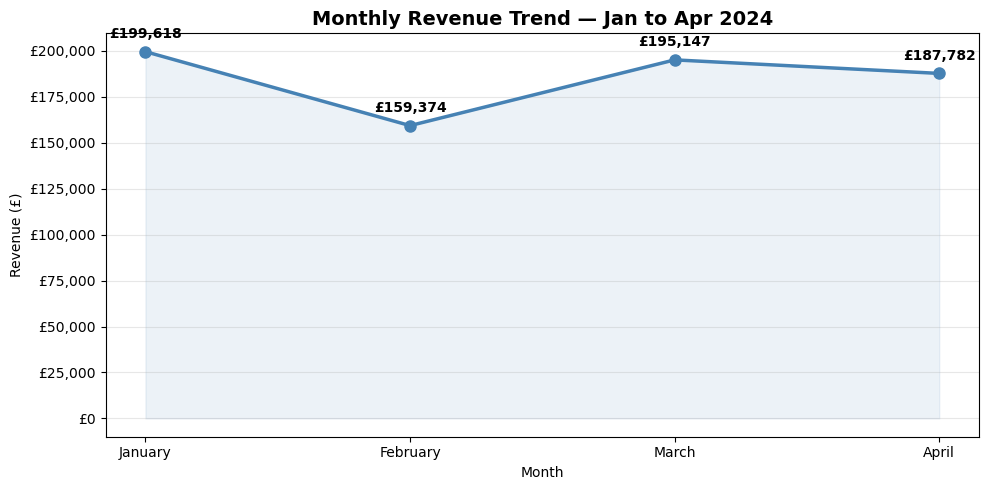

In [47]:
monthly_rev = (
    df.groupby('Journey Month Name', sort=False)['Price']
    .sum()
    .reindex(['January', 'February', 'March', 'April'])
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_rev.index, monthly_rev.values, marker='o', color=PRIMARY,
        lw=2.5, markersize=8, label='Monthly Revenue')
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.1, color=PRIMARY)

for i, (month, val) in enumerate(monthly_rev.items()):
    ax.annotate(f'£{val:,.0f}', xy=(i, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Monthly Revenue Trend — Jan to Apr 2024', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_monthly_revenue.png', dpi=150)
plt.show()

# Chart 2 — Top Routes by Revenue (Horizontal Bar)


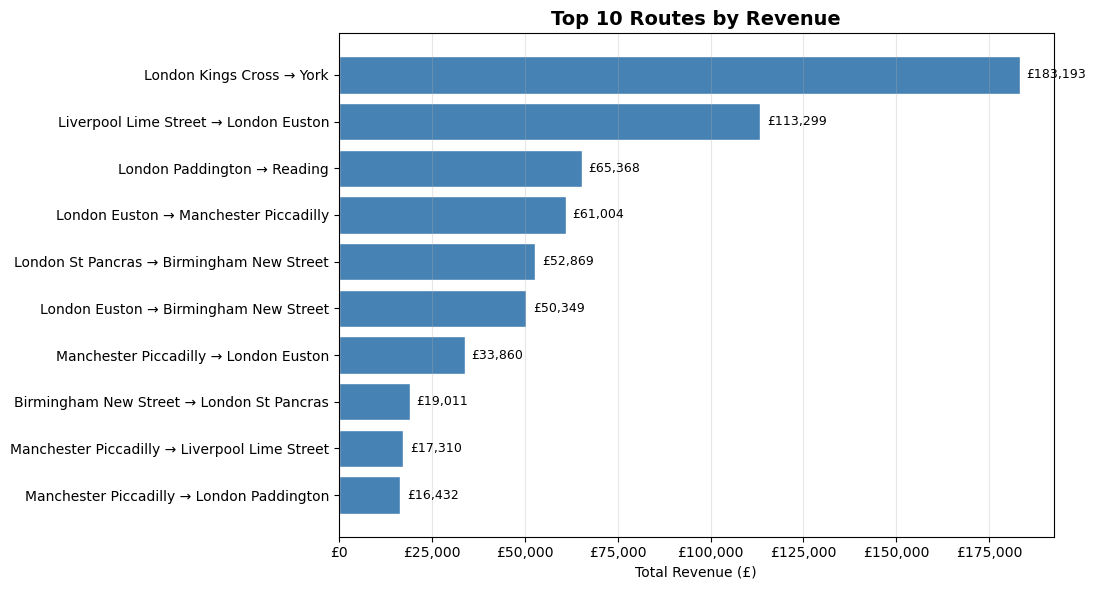

In [48]:
top_routes = (
    df.groupby('Route')['Price']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(top_routes.index, top_routes.values, color=PRIMARY, edgecolor='white')
ax.bar_label(bars, labels=[f'£{v:,.0f}' for v in top_routes.values],
             padding=5, fontsize=9)

ax.set_title('Top 10 Routes by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_top_routes_revenue.png', dpi=150)
plt.show()

# Chart 3 — Revenue by Ticket Type (Donut)


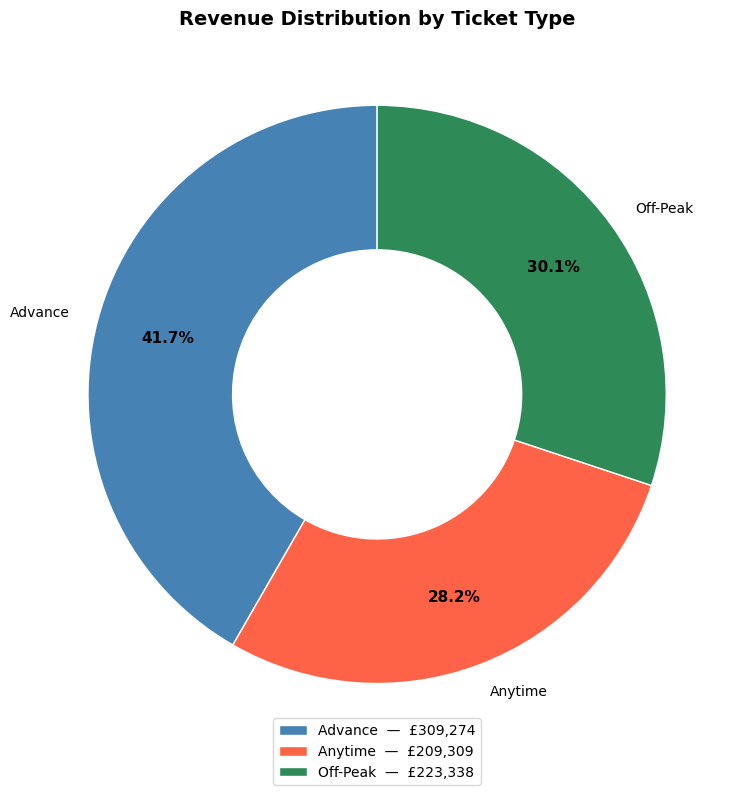

In [49]:
rev_by_type = df.groupby('Ticket Type', observed=True)['Price'].sum()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    rev_by_type.values,
    labels=rev_by_type.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=COLORS[:len(rev_by_type)],
    wedgeprops=dict(width=0.5, edgecolor='white'),
    pctdistance=0.75
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

# Add £ value annotations inside legend
legend_labels = [f'{t}  —  £{v:,.0f}' for t, v in zip(rev_by_type.index, rev_by_type.values)]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.05), fontsize=10)

ax.set_title('Revenue Distribution by Ticket Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_revenue_ticket_type.png', dpi=150)
plt.show()

# Chart 4 — Journey Status Breakdown (Donut)


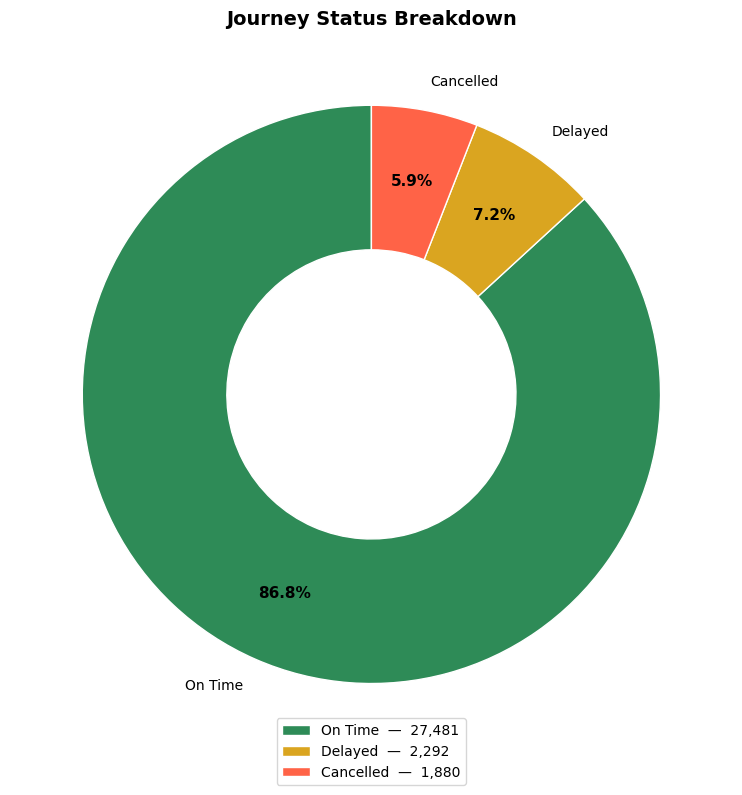

In [50]:
status_counts = df['Journey Status'].value_counts()
status_colors = {'On Time': 'seagreen', 'Delayed': 'goldenrod', 'Cancelled': 'tomato'}
colors_ordered = [status_colors[s] for s in status_counts.index]

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_ordered,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    pctdistance=0.75
)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')

legend_labels = [f'{s}  —  {v:,}' for s, v in zip(status_counts.index, status_counts.values)]
ax.legend(wedges, legend_labels, loc='lower center',
          bbox_to_anchor=(0.5, -0.05), fontsize=10)

ax.set_title('Journey Status Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_journey_status.png', dpi=150)
plt.show()

# Chart 5 — Delay Reasons Ranking (Horizontal Bar)

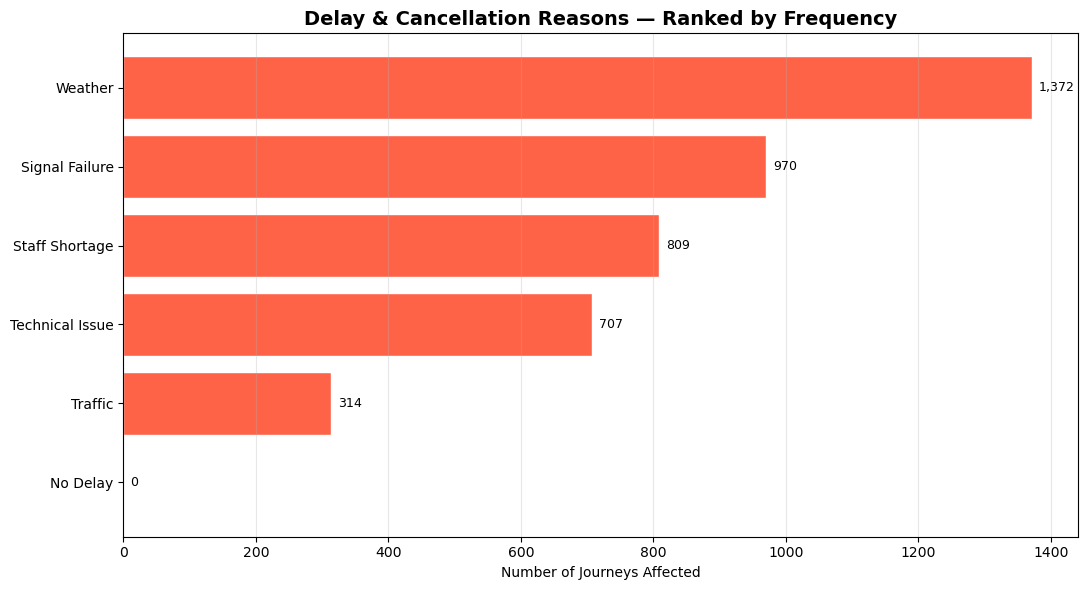

In [51]:
delay_reasons = (
    df[df['Reason for Delay'] != 'No Delay']
    ['Reason for Delay']
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(delay_reasons.index, delay_reasons.values, color=SECONDARY, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in delay_reasons.values],
             padding=5, fontsize=9)

ax.set_title('Delay & Cancellation Reasons — Ranked by Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Journeys Affected')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('chart5_delay_reasons.png', dpi=150)
plt.show()

# Chart 6 — Refund Rate by Journey Status (Bar)


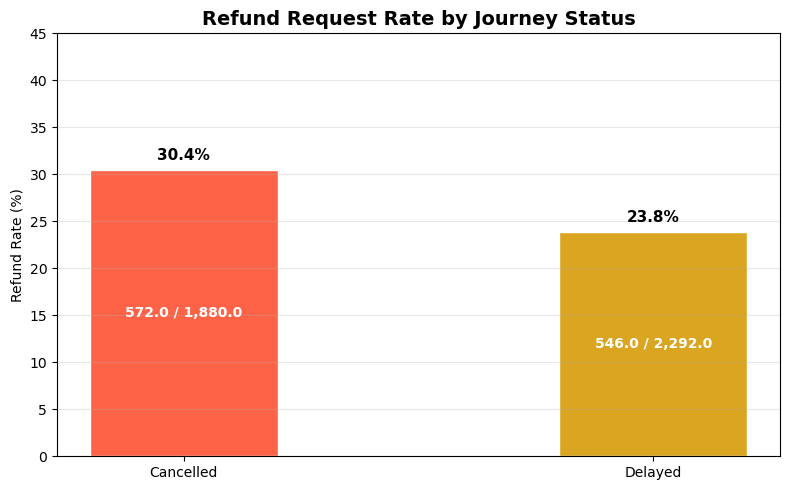

In [62]:
refund_summary = (
    df[df['Journey Status'].isin(['Delayed', 'Cancelled'])]
    .groupby('Journey Status', observed=True)
    .apply(lambda x: pd.Series({
        'Total':        len(x),
        'Refunded':     (x['Refund Request'].str.lower() == 'yes').sum(),
        'Refund Rate %': (x['Refund Request'].str.lower() == 'yes').mean() * 100
    }) ,include_groups=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(refund_summary['Journey Status'],
              refund_summary['Refund Rate %'],
              color=[SECONDARY, 'goldenrod'], edgecolor='white', width=0.4)

ax.bar_label(bars, labels=[f"{v:.1f}%" for v in refund_summary['Refund Rate %']],
             padding=5, fontsize=11, fontweight='bold')

# Secondary annotation — absolute counts
for i, row in refund_summary.iterrows():
    ax.text(i, row['Refund Rate %'] / 2,
            f"{row['Refunded']:,} / {row['Total']:,}",
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_title('Refund Request Rate by Journey Status', fontsize=14, fontweight='bold')
ax.set_ylabel('Refund Rate (%)')
ax.set_ylim(0, 45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart6_refund_rate.png', dpi=150)
plt.show()

## library

# Chart 7 — Rides by Day of Week (Bar)


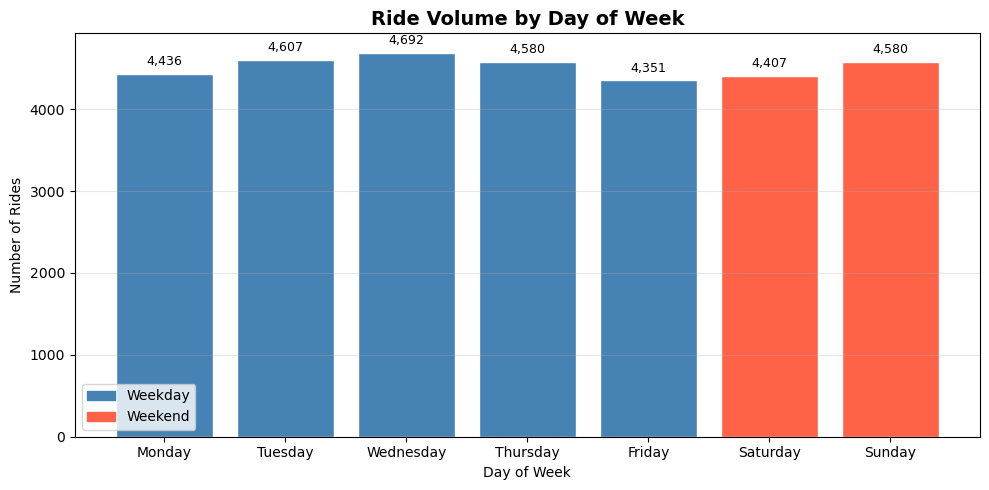

In [53]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

rides_by_day = (
    df['Journey Day Name']
    .value_counts()
    .reindex(day_order)
)

weekend_mask = [d in ['Saturday', 'Sunday'] for d in day_order]
bar_colors   = [SECONDARY if w else PRIMARY for w in weekend_mask]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(rides_by_day.index, rides_by_day.values,
              color=bar_colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in rides_by_day.values],
             padding=4, fontsize=9)

ax.set_title('Ride Volume by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Rides')
ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=PRIMARY,   label='Weekday'),
    Patch(color=SECONDARY, label='Weekend')
], fontsize=10)

plt.tight_layout()
plt.savefig('chart7_rides_by_day.png', dpi=150)
plt.show()

## 📋 Week 3 — Forecasting Questions

| # | Question |
|---|----------|
| **Ride Demand** | |
| 1 | Build a model to predict the daily ride count for each day in May 2024, and visualize the historical trend alongside the forecast. |
| **Revenue Forecast** | |
| 2 | Build a model to predict the daily revenue for each day in May 2024, and visualize the historical trend alongside the forecast. |
| **Ticket Class & Type Demand** | |
| 3 | Forecast the total demand split for May 2024 by ticket class and ticket type, and visualize the expected volume for each segment. |

In [54]:
!pip install prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet

## Q1 — Forecast Daily Ride Count for May 2024


18:39:41 - cmdstanpy - INFO - Chain [1] start processing
18:39:41 - cmdstanpy - INFO - Chain [1] done processing


── May 2024 Daily Ride Forecast ──
        ds  yhat  yhat_lower  yhat_upper
2024-05-01   282  233.122434  333.646082
2024-05-02   275  224.516130  324.477798
2024-05-03   262  215.012041  314.033347
2024-05-04   265  213.365250  315.747460
2024-05-05   275  225.049055  325.930712
2024-05-06   253  204.748434  303.080916
2024-05-07   262  209.461506  310.880984
2024-05-08   283  231.340547  333.293142
2024-05-09   276  226.566991  327.618485
2024-05-10   263  212.057115  314.015453
2024-05-11   266  210.040273  316.731364
2024-05-12   276  227.800499  325.782179
2024-05-13   253  203.505852  306.125586
2024-05-14   263  214.082409  315.172134
2024-05-15   283  233.149939  334.075970
2024-05-16   277  227.424223  330.638620
2024-05-17   263  211.929260  312.708985
2024-05-18   266  216.115608  318.543472
2024-05-19   277  225.826135  325.034395
2024-05-20   254  204.058346  304.849040
2024-05-21   264  211.840885  316.463871
2024-05-22   284  233.655926  335.205701
2024-05-23   277  226.

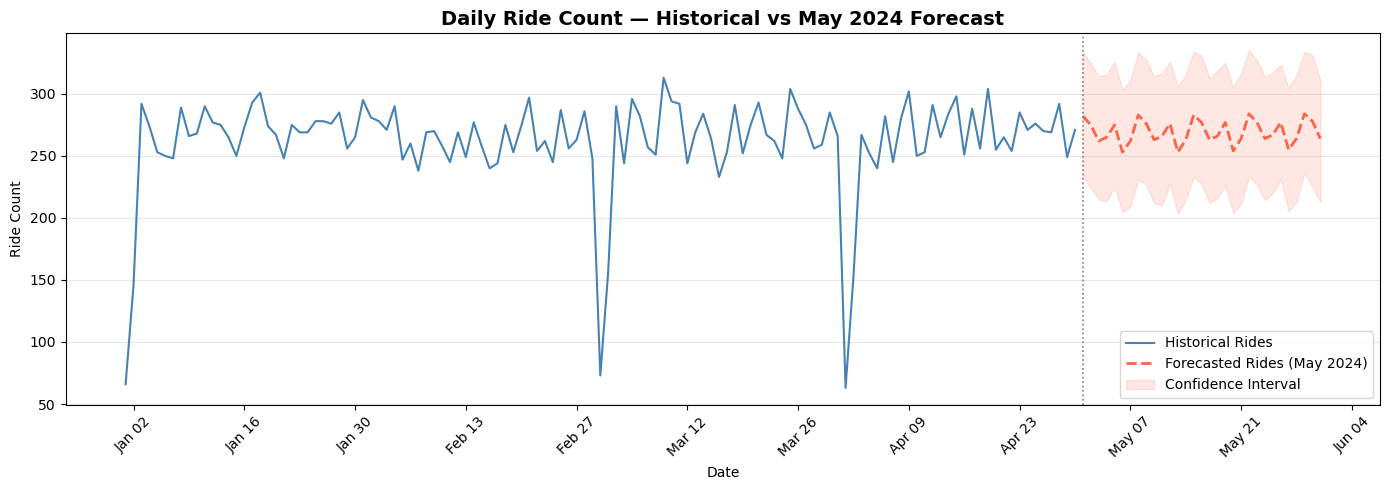

In [55]:
# ── Daily ride count ──────────────────────────────────────────────────────────
daily_rides = (
    df.groupby('Date of Journey')
    .size()
    .rename('y')
    .reset_index()
    .rename(columns={'Date of Journey': 'ds'})
)

# ── Fit Prophet ───────────────────────────────────────────────────────────────
m1 = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,   # only 4 months of data
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m1.fit(daily_rides)

# ── Forecast May 2024 ─────────────────────────────────────────────────────────
future_rides = m1.make_future_dataframe(periods=31)
forecast_rides = m1.predict(future_rides)

may_rides = forecast_rides[forecast_rides['ds'] >= '2024-05-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
may_rides['yhat'] = may_rides['yhat'].clip(lower=0).round(0).astype(int)

print("── May 2024 Daily Ride Forecast ──")
print(may_rides.to_string(index=False))
print(f"\nTotal Forecasted Rides in May: {may_rides['yhat'].sum():,}")

# ── Chart 1 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_rides['ds'], daily_rides['y'],
        color='steelblue', lw=1.5, label='Historical Rides')
ax.plot(may_rides['ds'], may_rides['yhat'],
        color='tomato', lw=2, linestyle='--', label='Forecasted Rides (May 2024)')
ax.fill_between(may_rides['ds'],
                may_rides['yhat_lower'].clip(0),
                may_rides['yhat_upper'],
                color='tomato', alpha=0.15, label='Confidence Interval')
ax.axvline(pd.Timestamp('2024-05-01'), color='gray', linestyle=':', lw=1.2)

ax.set_title('Daily Ride Count — Historical vs May 2024 Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Ride Count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart7_forecast_rides.png', dpi=150)
plt.show()

## Q2 — Forecast Daily Revenue for May 2024


18:39:42 - cmdstanpy - INFO - Chain [1] start processing
18:39:42 - cmdstanpy - INFO - Chain [1] done processing


── May 2024 Daily Revenue Forecast ──
        ds    yhat  yhat_lower  yhat_upper
2024-05-01 6850.08 5414.729523 8144.961189
2024-05-02 6346.59 5067.537098 7633.569752
2024-05-03 6357.97 4953.222042 7736.071737
2024-05-04 5858.19 4475.431030 7286.040591
2024-05-05 6041.41 4636.384724 7328.896858
2024-05-06 6151.44 4760.337219 7471.839666
2024-05-07 6424.73 5067.019509 7786.030911
2024-05-08 6868.49 5483.853522 8255.089571
2024-05-09 6365.00 5084.866294 7772.069097
2024-05-10 6376.38 4945.427605 7752.164081
2024-05-11 5876.60 4582.572487 7203.042706
2024-05-12 6059.81 4750.761224 7354.307448
2024-05-13 6169.85 4690.343506 7517.008340
2024-05-14 6443.13 5163.366744 7733.894061
2024-05-15 6886.90 5534.503819 8213.352702
2024-05-16 6383.41 5155.835868 7853.835888
2024-05-17 6394.79 5012.565308 7778.322384
2024-05-18 5895.01 4599.150314 7281.003611
2024-05-19 6078.22 4706.439767 7477.508187
2024-05-20 6188.26 4833.592540 7682.200441
2024-05-21 6461.54 5142.016839 7789.923280
2024-05-22 6905.

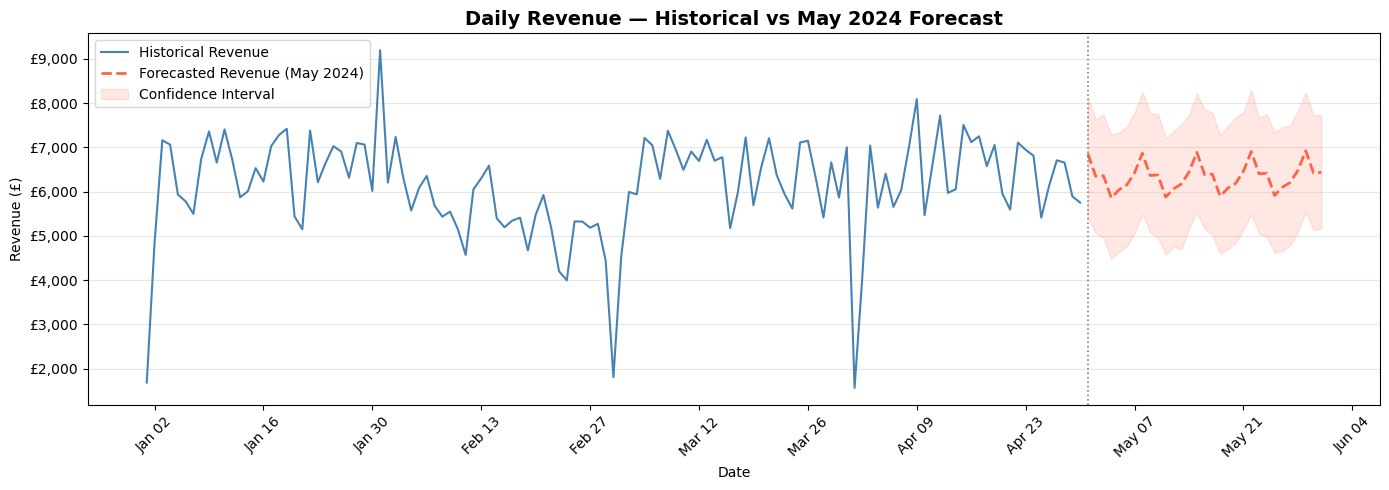

In [56]:
# ── Daily revenue ─────────────────────────────────────────────────────────────
daily_revenue = (
    df.groupby('Date of Journey')['Price']
    .sum()
    .reset_index()
    .rename(columns={'Date of Journey': 'ds', 'Price': 'y'})
)

# ── Fit Prophet ───────────────────────────────────────────────────────────────
m2 = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
m2.fit(daily_revenue)

# ── Forecast ──────────────────────────────────────────────────────────────────
future_rev = m2.make_future_dataframe(periods=31)
forecast_rev = m2.predict(future_rev)

may_rev = forecast_rev[forecast_rev['ds'] >= '2024-05-01'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
may_rev['yhat'] = may_rev['yhat'].clip(lower=0).round(2)

print("── May 2024 Daily Revenue Forecast ──")
print(may_rev.to_string(index=False))
print(f"\nTotal Forecasted Revenue in May: £{may_rev['yhat'].sum():,.2f}")

# ── Chart 2 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_revenue['ds'], daily_revenue['y'],
        color='steelblue', lw=1.5, label='Historical Revenue')
ax.plot(may_rev['ds'], may_rev['yhat'],
        color='tomato', lw=2, linestyle='--', label='Forecasted Revenue (May 2024)')
ax.fill_between(may_rev['ds'],
                may_rev['yhat_lower'].clip(0),
                may_rev['yhat_upper'],
                color='tomato', alpha=0.15, label='Confidence Interval')
ax.axvline(pd.Timestamp('2024-05-01'), color='gray', linestyle=':', lw=1.2)

ax.set_title('Daily Revenue — Historical vs May 2024 Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart8_forecast_revenue.png', dpi=150)
plt.show()

## Q3 — May 2024 Demand by Ticket Class & Type

18:39:42 - cmdstanpy - INFO - Chain [1] start processing
18:39:42 - cmdstanpy - INFO - Chain [1] done processing
18:39:43 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing
18:39:43 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing
18:39:43 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing
18:39:43 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing
18:39:43 - cmdstanpy - INFO - Chain [1] start processing
18:39:43 - cmdstanpy - INFO - Chain [1] done processing


── May 2024 Forecasted Demand by Segment ──
Ticket Class Ticket Type  Forecast_May
    Standard     Advance          3584
    Standard    Off-Peak          2181
    Standard     Anytime          1237
 First Class     Advance           395
 First Class    Off-Peak           241
 First Class     Anytime           144


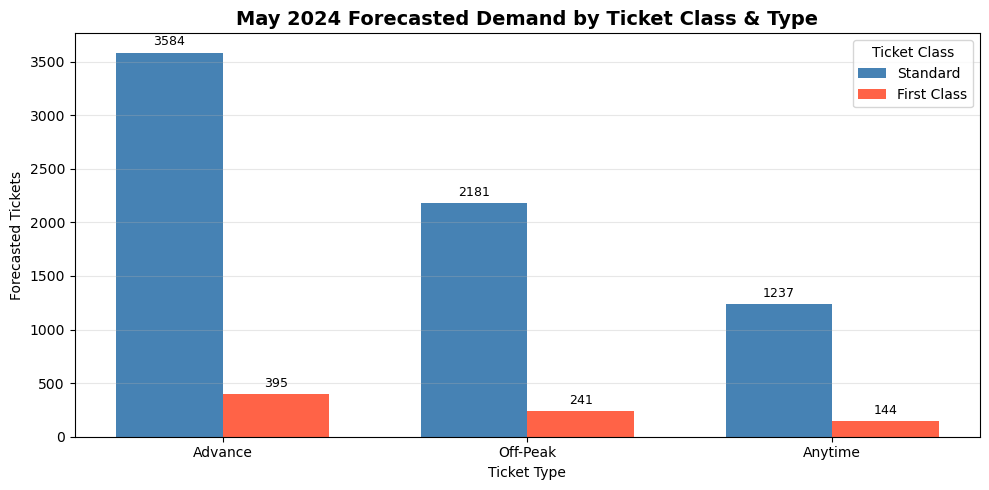

In [57]:
# ── Monthly volume per segment ────────────────────────────────────────────────
df['Journey Month'] = df['Date of Journey'].dt.to_period('M')

segment = (
    df.groupby(['Journey Month', 'Ticket Class', 'Ticket Type'], observed=True)
    .size()
    .reset_index(name='y')
)
segment['ds'] = segment['Journey Month'].dt.to_timestamp()

segments = [
    ('Standard',    'Advance'),  ('Standard',    'Off-Peak'), ('Standard',    'Anytime'),
    ('First Class', 'Advance'),  ('First Class', 'Off-Peak'), ('First Class', 'Anytime')
]

may_forecast = []

for cls, typ in segments:
    ts = (
        segment[
            (segment['Ticket Class'] == cls) &
            (segment['Ticket Type'] == typ)
        ][['ds', 'y']]
        .sort_values('ds')
        .reset_index(drop=True)
    )

    if len(ts) < 2:
        may_forecast.append({'Ticket Class': cls, 'Ticket Type': typ, 'Forecast_May': 0})
        continue

    try:
        m = Prophet(
            weekly_seasonality=False,
            yearly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )
        m.fit(ts)
        future = m.make_future_dataframe(periods=1, freq='MS')
        pred = m.predict(future)
        val = max(round(pred[pred['ds'] >= '2024-05-01']['yhat'].values[0]), 0)
    except Exception:
        val = round(ts['y'].mean())

    may_forecast.append({'Ticket Class': cls, 'Ticket Type': typ, 'Forecast_May': val})

q3_df = pd.DataFrame(may_forecast)
print("── May 2024 Forecasted Demand by Segment ──")
print(q3_df.to_string(index=False))

# ── Chart 3: Grouped bar ──────────────────────────────────────────────────────
ticket_types = ['Advance', 'Off-Peak', 'Anytime']
classes      = ['Standard', 'First Class']
x     = np.arange(len(ticket_types))
width = 0.35
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(10, 5))

for i, cls in enumerate(classes):
    vals = [
        q3_df[(q3_df['Ticket Class'] == cls) & (q3_df['Ticket Type'] == t)]['Forecast_May'].values[0]
        for t in ticket_types
    ]
    bars = ax.bar(x + i * width, vals, width, label=cls, color=colors[i])
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)

ax.set_title('May 2024 Forecasted Demand by Ticket Class & Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Ticket Type')
ax.set_ylabel('Forecasted Tickets')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(ticket_types)
ax.legend(title='Ticket Class')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart9_forecast_segments.png', dpi=150)
plt.show()